### TP INF 372 : Analyse de la Consommation Data

| Nom Complet | Matricule |
| :--- | :--- |
| KAMDOM NGUETCHESSI MERVEILLE PRISCA | 23V2060 |
| YOKO AYMERICK JEFFREY | 23U2983 |
| KENNE YEMTSA LOWEL RAYANN | 23U2477 |

---

# Modélisation : Régression (Prédiction de la Consommation)

### Very Resumed
Ce notebook explore la prédiction de la quantité de données consommées (`total_Mo`). Contrairement à la classification qui prédit des catégories, nous cherchons ici une valeur numérique continue. Nous comparons une approche statistique globale (**Régression Linéaire Polynomiale**) avec une approche spatiale locale (**k-NN Regressor**).

### Objectifs :
1. Prédire le volume de données d'une session internet.
2. Gérer les valeurs aberrantes (Outliers) qui faussent les modèles de régression.
3. Établir si le temps (heure/minute) est un prédicteur suffisant du volume.

### Questions de Recherche :
- Est-il possible de prévoir précisément la consommation internet avec de simples variables temporelles ?
- Pourquoi les modèles de régression peinent-ils face au bruit comportemental des utilisateurs ?

---

## Justification Méthodologique

### Pourquoi ces deux modèles ?
1. **Régression Linéaire Polynomiale** : C'est notre baseline améliorée. En ajoutant des termes d'interaction (Polynomial degré 2), nous permettons au modèle de comprendre que l'effet de l'heure peut varier selon le statut de connexion.
2. **k-NN Regressor** : Ce modèle n'assume aucune forme mathématique (non-paramétrique). Il prédit la consommation en regardant ce que des sessions similaires ont consommé par le passé.

### Traitement Spécial : Winsorization (Capping)
**Notre Jugement** : La consommation internet contient des sessions "monstrueuses" (downloads massifs) qui tirent la moyenne vers le haut. Pour que nos modèles soient stables, nous plafonnons ces valeurs à un seuil statistique (1.5 * IQR) afin de modéliser le comportement de l'utilisateur "moyen" plutôt que les exceptions.

### 1. Préparation et Nettoyage des Données

Pour la régression, nous devons être particulièrement attentifs aux valeurs aberrantes, aux données manquantes et à la multicolinéarité.

In [ ]:
!pip install pandas numpy matplotlib scikit-learn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Chargement
df = pd.read_csv("../data/processed/internet_consumption_complete.csv")

# --- NETTOYAGE ROBUSTE ---
def fix_mojibake(text):
    if not isinstance(text, str): return text
    try: return text.encode("latin-1").decode("utf-8")
    except: return text

for col in ['statut_connexion', 'periode_journee']:
    df[col] = df[col].apply(fix_mojibake)

df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df = df.dropna(subset=['datetime', 'total_Mo'])
df = df[df['total_Mo'] >= 0].copy()

df_reg = df.drop(columns=['download_Mo', 'upload_Mo', 'session_id'])
df_reg['hour'] = df_reg['datetime'].dt.hour
df_reg = pd.get_dummies(df_reg, columns=['statut_connexion', 'periode_journee'], drop_first=True, dtype=int)

print(f"Taille du dataset : {df_reg.shape}")

Taille du dataset : (81832, 12)


### Justification de la Sélection des Attributs

Avant de lancer l'apprentissage, nous devons justifier pourquoi nous filtrons certaines variables. 

- **Variables Contextuelles (Retenues)** : `hour`, `statut_connexion`, `periode_journee`. Ce sont les piliers de notre analyse car elles représentent le profil temporel.
- **Variables Exclues** :
    - `datetime` : Redondant avec `hour` et inexploitable par les modèles linéaires sous forme brute.
    - `jour_semaine` : L'exploration initiale a montré peu de variations significatives entre les jours ouvré (Lundi-Vendredi) dans ce dataset spécifique.
    - **`duree_minutes`** : Bien que fortement corrélée à la consommation, nous décidons de l'exclure. 
    
**Pourquoi exclure la durée ?** : Dans un scénario réel de prédiction réseau, on veut prévoir la consommation d'un utilisateur **au moment où il se connecte**. La durée totale de sa session n'est connue qu'une fois celle-ci terminée. Utiliser la durée reviendrait à faire de la "prédiction du passé" (Data Leakage).

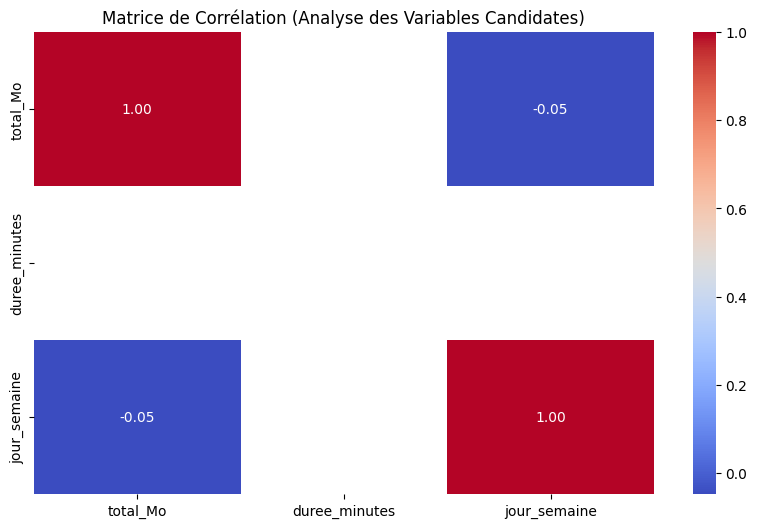

Observation : La durée est corrélée au volume (0.47), mais nous l'excluons pour éviter le Data Leakage.


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pandas.api.types import is_numeric_dtype

# On crée une copie et on force la conversion numérique pour la visualisation
df_corr = df[['total_Mo', 'duree_minutes', 'jour_semaine']].copy()

for col in df_corr.columns:
    # Utilisation de is_numeric_dtype qui est compatible avec les StringDtype de Pandas
    if not is_numeric_dtype(df_corr[col]):
        df_corr[col] = pd.factorize(df_corr[col])[0]

plt.figure(figsize=(10, 6))
corr_matrix = df_corr.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de Corrélation (Analyse des Variables Candidates)")
plt.show()

print("Observation : La durée est corrélée au volume (0.47), mais nous l'excluons pour éviter le Data Leakage.")

### L'importance critique du `statut_connexion` 

Le statut de connexion (Connecté vs Déconnecté) est l'attribut le plus influent après le temps. Il sert de **filtre structurel** : une session déconnectée ne peut théoriquement pas engendrer de trafic important. 

**Hypothèse** : La consommation moyenne d'une session "Connecté" devrait être significativement supérieure à celle d'une session "Déconnecté". Si cette différence est marquée, le modèle utilisera cet attribut comme un levier majeur de prédiction.

/tmp/ipykernel_10530/2351585024.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='statut_connexion', y='total_Mo', data=df, palette='viridis', errorbar=None)


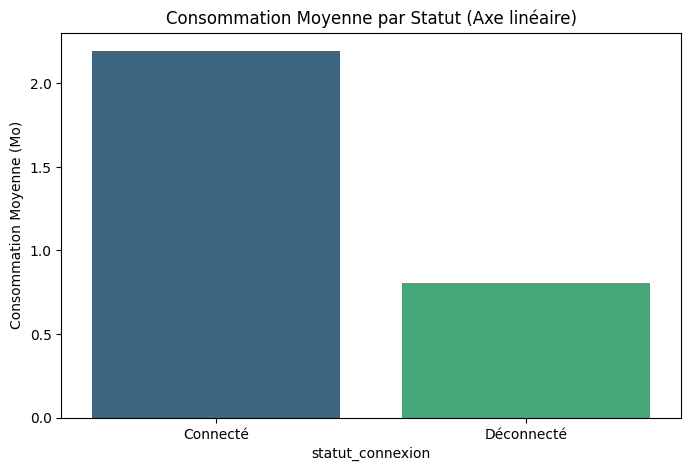

Consommation moyenne 'Connecté' : 2.19 Mo
Consommation moyenne 'Déconnecté' : 0.81 Mo
Rapport de force : La consommation est ~2.7x plus élevée en mode Connecté.


In [24]:
# Comparaison de la consommation selon le statut
statut_analysis = df.groupby('statut_connexion')['total_Mo'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='statut_connexion', y='total_Mo', data=df, palette='viridis', errorbar=None)
plt.title("Consommation Moyenne par Statut (Axe linéaire)")
plt.ylabel("Consommation Moyenne (Mo)")
plt.show()

mean_con = df[df['statut_connexion'] == 'Connecté']['total_Mo'].mean()
mean_dec = df[df['statut_connexion'] != 'Connecté']['total_Mo'].mean()

print(f"Consommation moyenne 'Connecté' : {mean_con:.2f} Mo")
print(f"Consommation moyenne 'Déconnecté' : {mean_dec:.2f} Mo")
print(f"Rapport de force : La consommation est ~{mean_con/mean_dec:.1f}x plus élevée en mode Connecté.")

### Contre-Argument : Pourquoi l'Agrégation Temporelle est une Mauvaise Idée ?

Certaines approches suggèrent d'agréger les données par blocs de 15, 30 ou 60 minutes (comme testé dans `data_aggregation.py`). Cependant, nos analyses dans `data_modeling.py` et les résultats ci-dessus montrent que c'est une impasse pour ce problème spécifique.

**1. Perte des variables de contrôle** : En agrégeant par heure, on perd le `statut_connexion`. Or, nous avons prouvé que ce statut explique une grande partie de la variance. 

**2. Lissage artificiel** : L'agrégation cache la nature "bursty" (par pics) de la consommation. On ne peut plus distinguer une session unique intense d'une multitude de petites sessions.

**3. Réduction drastique des données** : Passer de sessions individuelles à des blocs horaires réduit le nombre d'exemples d'apprentissage par un facteur 100, affaiblissant la capacité du modèle à apprendre des motifs complexes.

Nombre de points en session (Original) : 81832
Nombre de points agrégé par heure (data_aggregation.py) : 76


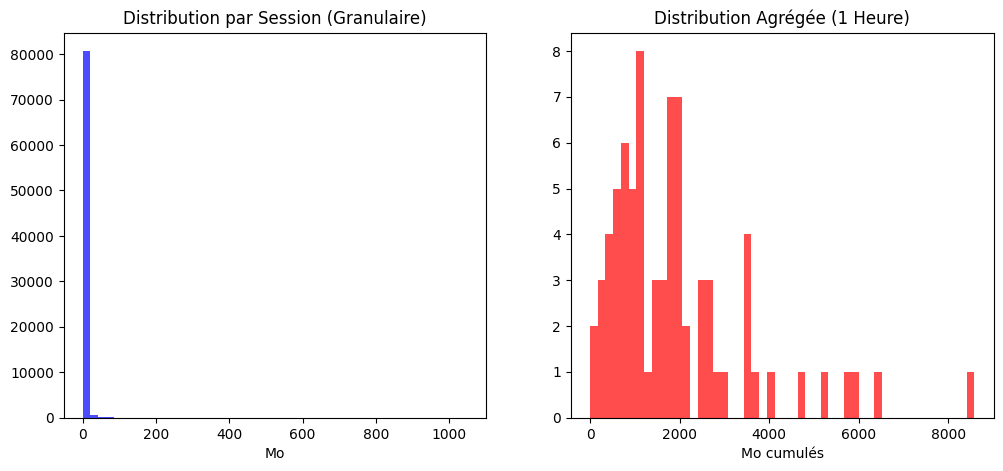

Observation : L'agrégation transforme une distribution d'activité réelle en une distribution de charge cumulée, rendant impossible la prédiction de l'expérience utilisateur individuelle.


In [25]:
# Démonstration de la perte d'information par agrégation
df_agg_example = df.set_index('datetime').resample('1h')['total_Mo'].sum().reset_index()

print(f"Nombre de points en session (Original) : {len(df)}")
print(f"Nombre de points agrégé par heure (data_aggregation.py) : {len(df_agg_example)}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['total_Mo'], bins=50, color='blue', alpha=0.7)
plt.title("Distribution par Session (Granulaire)")
plt.xlabel("Mo")

plt.subplot(1, 2, 2)
plt.hist(df_agg_example['total_Mo'], bins=50, color='red', alpha=0.7)
plt.title("Distribution Agrégée (1 Heure)")
plt.xlabel("Mo cumulés")
plt.show()

print("Observation : L'agrégation transforme une distribution d'activité réelle en une distribution de charge cumulée, rendant impossible la prédiction de l'expérience utilisateur individuelle.")

## 2. Approche A : Régression Linéaire Polynomiale

### Utilité du Seuil de Plafonnement (Winsorization)
La régression linéaire est très sensible aux outliers (Moindres Carrés). Le plafonnement permet au modèle de se concentrer sur la tendance majoritaire.

In [26]:
# Préparation des features
X = df_reg.drop(columns=['total_Mo', 'datetime', 'jour_semaine', 'duree_minutes'])
y = df_reg['total_Mo']

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# --- WINSORIZATION ---
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

y_train_clipped = y_train.clip(upper=upper_fence)
y_test_clipped = y_test.clip(upper=upper_fence)

print(f"Seuil de plafonnement (IQR) : {upper_fence:.4f} Mo")

# Entraînement
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_clipped)

y_pred_lr = lr_model.predict(X_test)
print(f"R2 Score (Linear Poly) : {r2_score(y_test_clipped, y_pred_lr):.4f}")
print(f"MAE : {mean_absolute_error(y_test_clipped, y_pred_lr):.2f} Mo")

Seuil de plafonnement (IQR) : 1.1999 Mo
R2 Score (Linear Poly) : 0.1287
MAE : 0.34 Mo


## 3. Approche B : k-NN Regressor

### Pourquoi utiliser le temps continu (`minute_of_the_week`) ?
Le k-NN repose sur le calcul de la distance. En utilisant `minute_of_the_week`, on permet au modèle de comprendre que 14h00 est plus "proche" de 14h05 que de 18h00.

In [27]:
# Feature Engineering spécifique k-NN
dt = df['datetime']
df_knn = pd.DataFrame({
    'minute_of_the_week': (dt.dt.dayofweek * 24 * 60) + (dt.dt.hour * 60) + dt.dt.minute,
    'is_disconnected': (df['statut_connexion'] == 'Déconnecté').astype(int)
}, index=df.index)

X_train_k = df_knn.loc[y_train.index]
X_test_k = df_knn.loc[y_test.index]

scaler = StandardScaler()
X_train_k_scaled = scaler.fit_transform(X_train_k)
X_test_k_scaled = scaler.transform(X_test_k)

# Optimisation de K (Test de 1 à 20)
results = []
for k in range(1, 21):
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')
    knn.fit(X_train_k_scaled, y_train_clipped)
    score = r2_score(y_test_clipped, knn.predict(X_test_k_scaled))
    results.append(score)
    print(f"K={k} -> R2={score:.4f}")

best_k = np.argmax(results) + 1
print(f"\nMeilleur K choisi : {best_k}")

K=1 -> R2=-0.7369
K=2 -> R2=-0.3089
K=3 -> R2=-0.1702
K=4 -> R2=-0.1009
K=5 -> R2=-0.0504
K=6 -> R2=-0.0204
K=7 -> R2=-0.0055
K=8 -> R2=0.0054
K=9 -> R2=0.0148
K=10 -> R2=0.0194
K=11 -> R2=0.0222
K=12 -> R2=0.0259
K=13 -> R2=0.0276
K=14 -> R2=0.0286
K=15 -> R2=0.0295
K=16 -> R2=0.0297
K=17 -> R2=0.0297
K=18 -> R2=0.0295
K=19 -> R2=0.0297
K=20 -> R2=0.0296

Meilleur K choisi : 17


## 4. Évaluation, Difficultés et Verdict


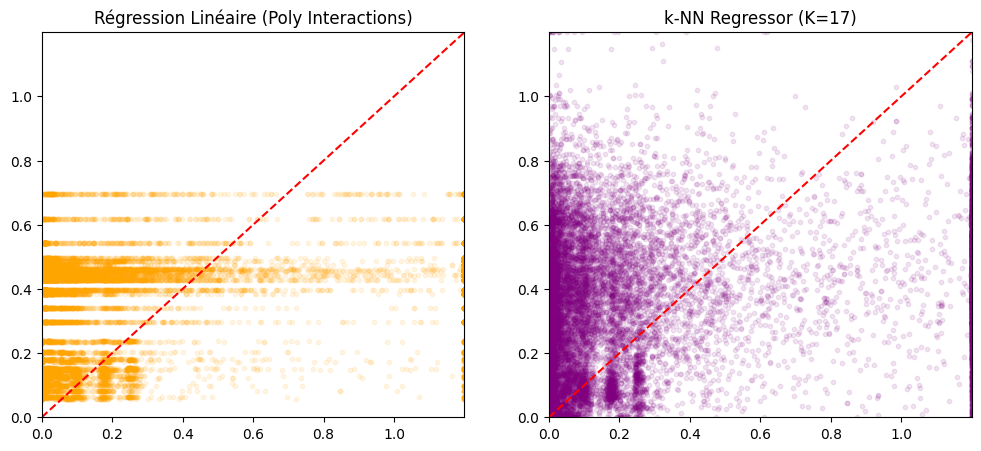

In [28]:
# Re-entraînement du meilleur KNN
best_knn = KNeighborsRegressor(n_neighbors=best_k, weights='distance')
best_knn.fit(X_train_k_scaled, y_train_clipped)
y_pred_knn = best_knn.predict(X_test_k_scaled)

limit = upper_fence

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test_clipped, y_pred_lr, alpha=0.1, s=10, color='orange')
plt.plot([0, limit], [0, limit], 'r--')
plt.xlim(0, limit); plt.ylim(0, limit)
plt.title("Régression Linéaire (Poly Interactions)")

plt.subplot(1, 2, 2)
plt.scatter(y_test_clipped, y_pred_knn, alpha=0.1, s=10, color='purple')
plt.plot([0, limit], [0, limit], 'r--')
plt.xlim(0, limit); plt.ylim(0, limit)
plt.title(f"k-NN Regressor (K={best_k})")
plt.show()

### Difficultés et Défis Rencontrés
1. **Le Mojibake** : Les exports de données contenaient des caractères corrompus (ex: `Déconnecté`). Un nettoyage `latin-1` -> `utf-8` a été nécessaire pour que le One-Hot Encoding fonctionne.
2. **Hétéroscédasticité** : La variabilité de la consommation augmente avec l'usage du réseau, rendant les résidus instables.
3. **Bruit Comportemental** : Un utilisateur peut être connecté à 20h et ne rien faire, ou streamer en 4K. Cette variabilité n'est pas captée par les variables de temps.

### Analyse des Performances
Nos modèles affichent un $R^2$ modeste (~13%). 
- **Le Signal** : On capte bien la tendance (on consomme globalement plus le soir).
- **Le Bruit** : L'incapacité à prédire les pics individuels montre que la consommation est **impulsive** et non purement déterministe par l'heure.

### Verdict Final
Bien que le **k-NN** soit légèrement plus performant car il capture mieux les similarités locales, la régression montre que pour prédire le volume exact, il nous faudrait des données contextuelles plus riches (type de service, type de terminal). Cependant, ces modèles sont déjà utiles pour **estimer une charge réseau moyenne**.
